In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

In [4]:
DATA_DIR = "data/"

# ── Weekly fruit & veg price ──────────────────────────────────────────────────
df_fruitveg = pd.read_csv(f"{DATA_DIR}cleaned_fruit_veg.csv")
df_fruitveg["date"] = pd.to_datetime(df_fruitveg["date"])
df_fruitveg["price"] = pd.to_numeric(df_fruitveg["price"], errors="coerce")
df_fruitveg = df_fruitveg[["date", "price"]].sort_values("date")

price_weekly = (
    df_fruitveg
    .groupby("date", as_index=False)["price"]
    .mean()
    .dropna()
    .sort_values("date")
    .set_index("date")["price"]
)

print(f"Price weekly: {len(price_weekly)} rows | {price_weekly.index[0].date()} → {price_weekly.index[-1].date()}")

# ── Weekly fuel prices ────────────────────────────────────────────────────────
fuel1 = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2003_to_2017.csv")
fuel2 = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2018_to_now.csv")
df_fuel = pd.concat([fuel1, fuel2], ignore_index=True)

# Find Date column and ULSP column
date_col  = [c for c in df_fuel.columns if c.strip().lower() == "date"][0]
ulsp_col  = [c for c in df_fuel.columns if "ulsp" in c.lower()][0]

df_fuel["date"]       = pd.to_datetime(df_fuel[date_col], dayfirst=True)
df_fuel["fuel_price"] = pd.to_numeric(df_fuel[ulsp_col], errors="coerce")
df_fuel = df_fuel[["date", "fuel_price"]].sort_values("date").dropna()
df_fuel = df_fuel[df_fuel["date"] >= price_weekly.index.min()]

fuel_weekly = (
    df_fuel
    .groupby("date", as_index=False)["fuel_price"]
    .mean()
    .set_index("date")["fuel_price"]
)

print(f"Fuel weekly:  {len(fuel_weekly)} rows | {fuel_weekly.index[0].date()} → {fuel_weekly.index[-1].date()}")

Price weekly: 527 rows | 2015-01-09 → 2026-02-16
Fuel weekly:  580 rows | 2015-01-12 → 2026-02-16


In [7]:
# ── Monthly CPI ───────────────────────────────────────────────────────────────
raw_cpi = pd.read_excel(
    f"{DATA_DIR}consumerpriceinflationdetailedreferencetables.xlsx",
    sheet_name="Table 15a, 15b, 15c",
    skiprows=5,
    header=0
)

# Strip leading/trailing spaces from all column names
raw_cpi.columns = raw_cpi.columns.str.strip()

months   = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
year_col = "Unnamed: 1"

cpi_rows = raw_cpi[raw_cpi[year_col].astype(str).str.match(r"^\d{4}$", na=False)].copy()
cpi_rows = cpi_rows[[year_col] + months].copy()
cpi_rows.columns = ["year"] + months
cpi_rows["year"] = cpi_rows["year"].astype(int)

cpi_long = cpi_rows.melt(id_vars="year", value_vars=months, var_name="month", value_name="cpi")
cpi_long["cpi"] = pd.to_numeric(
    cpi_long["cpi"].astype(str).str.replace("..", "", regex=False).str.strip(),
    errors="coerce"
)
cpi_long["date"] = pd.to_datetime(
    cpi_long["year"].astype(str) + " " + cpi_long["month"] + " 01",
    format="%Y %b %d"
)
cpi_monthly = cpi_long.dropna(subset=["cpi"]).set_index("date")["cpi"].sort_index()

print(f"CPI monthly: {len(cpi_monthly)} rows | {cpi_monthly.index[0].date()} → {cpi_monthly.index[-1].date()}")

CPI monthly: 944 rows | 1998-01-01 → 2026-01-01


In [8]:
raw_api = pd.read_csv(f"{DATA_DIR}API_20260129.csv")
raw_api["date"] = pd.to_datetime(raw_api["date"])
raw_api["api"]  = pd.to_numeric(raw_api["index"], errors="coerce")
api_monthly = (
    raw_api[["date","api"]].dropna()
    .set_index("date")["api"]
    .sort_index()
)
print(f"API monthly:  {len(api_monthly)} rows | {api_monthly.index[0].date()} → {api_monthly.index[-1].date()}")

API monthly:  14981 rows | 2014-01-01 → 2025-11-01


In [10]:
raw_fert = pd.read_excel(
    f"{DATA_DIR}GBFertiliserPriceSeries.xlsx",
    sheet_name="GB Fertiliser Price Series ",
    skiprows=13,
    dtype=str
)

print("Fert columns:", raw_fert.columns.tolist())
print("\nFert first 5 rows:")
print(raw_fert.iloc[:5, :6])

Fert columns: ['Unnamed: 0', 'Month', 'AN – UK produced (34.5% N)', 'Unnamed: 3', 'AN – imported* \n(34.5% N)', 'Unnamed: 5', 'Granular Urea - standard specification (46% N)', 'Unnamed: 7', 'UAN (30% N w/w kg per 100kg)', 'Unnamed: 9', 'Muriate of Potash (MOP)', 'Unnamed: 11', 'Diammonium Phosphate (DAP)', 'Unnamed: 13', 'Triple Super Phosphate (TSP)', 'Unnamed: 15', 'Polysulphate', 'Unnamed: 17', 'Nitrate Sulphur (26N + 30-37SO3)', 'Unnamed: 19']

Fert first 5 rows:
  Unnamed: 0                Month AN – UK produced (34.5% N) Unnamed: 3  \
0        NaN  2017-01-01 00:00:00         239.27272727272728          →   
1        NaN  2017-02-01 00:00:00                      248.5          →   
2        NaN  2017-03-01 00:00:00         244.46666666666667          ↘   
3        NaN  2017-04-01 00:00:00         237.66666666666666          →   
4        NaN  2017-05-01 00:00:00         209.20833333333334          ↓   

  AN – imported* \n(34.5% N) Unnamed: 5  
0         232.57142857142858       

In [11]:
raw_fert = pd.read_excel(
    f"{DATA_DIR}GBFertiliserPriceSeries.xlsx",
    sheet_name="GB Fertiliser Price Series ",
    skiprows=13,
    dtype=str
)

an_col = "AN – UK produced (34.5% N)"

raw_fert["date"]       = pd.to_datetime(raw_fert["Month"], errors="coerce")
raw_fert["fertiliser"] = pd.to_numeric(raw_fert[an_col], errors="coerce")

fert_monthly = (
    raw_fert[["date","fertiliser"]].dropna()
    .set_index("date")["fertiliser"]
    .sort_index()
)

print(f"Fert monthly: {len(fert_monthly)} rows | {fert_monthly.index[0].date()} → {fert_monthly.index[-1].date()}")

Fert monthly: 93 rows | 2017-01-01 → 2026-01-01


In [13]:
raw_sppi = pd.read_csv(
    f"{DATA_DIR}series-210226.csv",
    names=["period","value"]
)
raw_sppi = raw_sppi[raw_sppi["period"].str.match(r"^\d{4} Q[1-4]$", na=False)].copy()
raw_sppi["sppi"] = pd.to_numeric(raw_sppi["value"], errors="coerce")

# Parse "YYYY QN" manually
def quarter_to_date(s):
    year, q = s.split(" Q")
    month = (int(q) - 1) * 3 + 1
    return pd.Timestamp(year=int(year), month=month, day=1)

raw_sppi["date"] = raw_sppi["period"].apply(quarter_to_date)

sppi_quarterly = (
    raw_sppi[["date","sppi"]].dropna()
    .set_index("date")["sppi"]
    .sort_index()
)
print(f"SPPI quarterly: {len(sppi_quarterly)} rows | {sppi_quarterly.index[0].date()} → {sppi_quarterly.index[-1].date()}")

SPPI quarterly: 119 rows | 1996-01-01 → 2025-07-01


In [16]:
weekly_idx = price_weekly.index

def locf_to_weekly(series, weekly_index):
    # Deduplicate by taking the mean for any duplicate dates
    series = series.groupby(series.index).mean()
    combined = series.reindex(series.index.union(weekly_index))
    combined = combined.ffill()
    return combined.reindex(weekly_index)

cpi_w  = locf_to_weekly(cpi_monthly,    weekly_idx)
api_w  = locf_to_weekly(api_monthly,    weekly_idx)
fert_w = locf_to_weekly(fert_monthly,   weekly_idx)
sppi_w = locf_to_weekly(sppi_quarterly, weekly_idx)
fuel_w = locf_to_weekly(fuel_weekly,    weekly_idx)

df = pd.DataFrame({
    "price":      price_weekly.values,
    "fuel_price": fuel_w.values,
    "cpi":        cpi_w.values,
    "api":        api_w.values,
    "fertiliser": fert_w.values,
    "sppi":       sppi_w.values,
}, index=weekly_idx).dropna()

print(f"\nAligned dataset: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")


Aligned dataset: (427, 6) | 2017-01-06 → 2026-02-16


In [17]:
scaler       = StandardScaler()
price_scaler = StandardScaler()

data_scaled = scaler.fit_transform(df.values)
price_scaler.fit(df[["price"]].values)

SEQ_LEN  = 52
PRED_LEN = 1

def make_sequences(data, seq_len, pred_len):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len : i + seq_len + pred_len, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_sequences(data_scaled, SEQ_LEN, PRED_LEN)
print(f"Sequences: X={X.shape}, y={y.shape}")

n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

X_train, y_train = X[:n_train],       y[:n_train]
X_val,   y_val   = X[n_train:n_val],  y[n_train:n_val]
X_test,  y_test  = X[n_val:],         y[n_val:]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32, shuffle=True
)

Sequences: X=(375, 52, 6), y=(375, 1)
Train: 262 | Val: 56 | Test: 57


In [20]:
class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = int(expand * d_model)

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )
        self.act     = nn.SiLU()
        self.x_proj  = nn.Linear(self.d_inner, d_state * 2 + self.d_inner, bias=False)
        self.dt_proj = nn.Linear(self.d_inner, self.d_inner, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        A = A.expand(self.d_inner, -1)
        self.A_log   = nn.Parameter(torch.log(A))
        self.D       = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj= nn.Linear(self.d_inner, d_model, bias=False)
        self.norm    = nn.LayerNorm(d_model)

    def ssm(self, x):
        B, L, d = x.shape
        A = -torch.exp(self.A_log)
        x_proj = self.x_proj(x)
        delta, B_mat, C = torch.split(
            x_proj, [self.d_inner, self.d_state, self.d_state], dim=-1
        )
        delta = nn.functional.softplus(self.dt_proj(delta))  # ← fixed
        dA    = torch.exp(torch.einsum("bld,dn->bldn", delta, A))
        dB    = torch.einsum("bld,bln->bldn", delta, B_mat)

        h  = torch.zeros(B, d, self.d_state, device=x.device)
        ys = []
        for i in range(L):
            h  = dA[:, i] * h + dB[:, i] * x[:, i, :].unsqueeze(-1)
            yi = torch.einsum("bdn,bn->bd", h, C[:, i])
            ys.append(yi)
        y = torch.stack(ys, dim=1)
        return y + x * self.D

    def forward(self, x):
        residual = x
        x  = self.norm(x)
        xz = self.in_proj(x)
        x_proj, z = xz.chunk(2, dim=-1)
        x_proj = self.conv1d(x_proj.transpose(1,2))[..., :x.shape[1]].transpose(1,2)
        x_proj = self.act(x_proj)
        y = self.ssm(x_proj)
        y = y * self.act(z)
        return self.out_proj(y) + residual


class MambaForecast(nn.Module):
    def __init__(self, input_dim, d_model=64, n_layers=2,
                 d_state=16, pred_len=1, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.layers     = nn.ModuleList([
            MambaBlock(d_model, d_state=d_state) for _ in range(n_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(d_model, pred_len)

    def forward(self, x):
        x = self.input_proj(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        x = self.dropout(x)
        return self.head(x[:, -1, :])

In [21]:
model = MambaForecast(
    input_dim = X_train.shape[2],
    d_model   = 64,
    n_layers  = 2,
    d_state   = 16,
    pred_len  = PRED_LEN,
    dropout   = 0.1
)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

EPOCHS    = 150
best_val  = float("inf")
patience  = 20
wait      = 0
train_losses, val_losses = [], []
best_state = None

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t).item()

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.4f}")


Parameters: 129,665
Epoch  25 | Train: 0.1566 | Val: 0.7362
Early stopping at epoch 30
Best val loss: 0.3453


In [22]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t).numpy()
    test_true = y_test_t.numpy()

test_pred_inv = price_scaler.inverse_transform(test_pred)
test_true_inv = price_scaler.inverse_transform(test_true)

mae  = np.mean(np.abs(test_pred_inv - test_true_inv))
rmse = np.sqrt(np.mean((test_pred_inv - test_true_inv) ** 2))
mape = np.mean(np.abs((test_true_inv - test_pred_inv) / (np.abs(test_true_inv) + 1e-8))) * 100
naive_err = np.mean(np.abs(np.diff(df["price"].values)))
mase = mae / naive_err

print(f"\n══ TEST SET METRICS ══")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"MASE: {mase:.4f}")



══ TEST SET METRICS ══
MAE:  0.2003
RMSE: 0.2686
MAPE: 11.93%
MASE: 1.7080


In [23]:
seq = torch.FloatTensor(data_scaled[-SEQ_LEN:]).unsqueeze(0)
forecasts = []

model.eval()
with torch.no_grad():
    for _ in range(52):
        pred = model(seq).item()
        forecasts.append(pred)
        new_step    = seq[0, -1, :].clone()
        new_step[0] = pred
        seq = torch.cat([seq[:, 1:, :], new_step.unsqueeze(0).unsqueeze(0)], dim=1)

fc_inv = price_scaler.inverse_transform(
    np.array(forecasts).reshape(-1, 1)
).flatten()

fc_dates = pd.date_range(df.index[-1] + pd.Timedelta(weeks=1), periods=52, freq="W")

print(f"\n══ 52-WEEK FORECAST SUMMARY ══")
print(f"Mean: {fc_inv.mean():.4f} | Min: {fc_inv.min():.4f} | Max: {fc_inv.max():.4f}")


══ 52-WEEK FORECAST SUMMARY ══
Mean: 1.8104 | Min: 1.6576 | Max: 1.8165


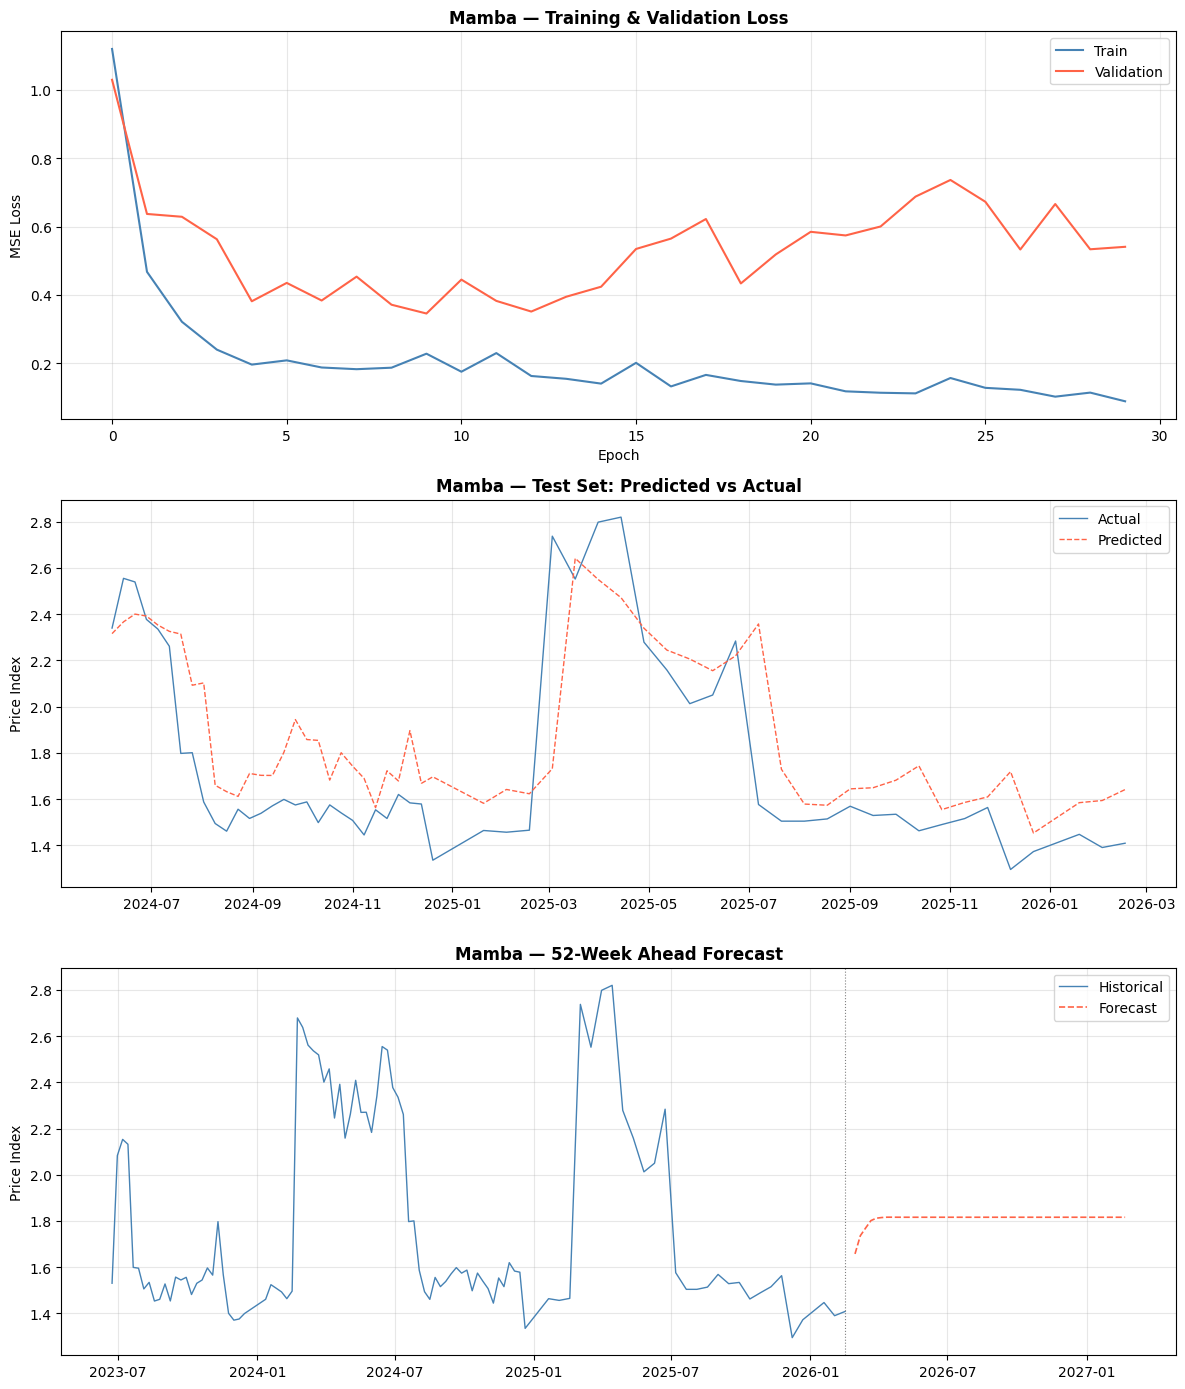

Plot saved: mamba_forecast.png


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Training curve
axes[0].plot(train_losses, label="Train", color="steelblue")
axes[0].plot(val_losses,   label="Validation", color="tomato")
axes[0].set_title("Mamba — Training & Validation Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test: predicted vs actual
test_dates = df.index[-len(test_true_inv):]
axes[1].plot(test_dates, test_true_inv.flatten(),  label="Actual",    color="steelblue", linewidth=1.0)
axes[1].plot(test_dates, test_pred_inv.flatten(),  label="Predicted", color="tomato",    linewidth=1.0, linestyle="--")
axes[1].set_title("Mamba — Test Set: Predicted vs Actual", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price Index")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 52-week forecast
hist_plot = df["price"].iloc[-104:]
axes[2].plot(hist_plot.index, hist_plot.values,  color="steelblue", linewidth=1.0, label="Historical")
axes[2].plot(fc_dates,        fc_inv,            color="tomato",    linewidth=1.2, linestyle="--", label="Forecast")
axes[2].axvline(df.index[-1], color="grey", linestyle=":", linewidth=0.8)
axes[2].set_title("Mamba — 52-Week Ahead Forecast", fontweight="bold")
axes[2].set_ylabel("Price Index")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mamba_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: mamba_forecast.png")

In [25]:
import scipy.stats as stats

model.eval()
with torch.no_grad():
    train_pred = model(X_train_t).numpy()
    val_pred   = model(X_val_t).numpy()
    test_pred  = model(X_test_t).numpy()

train_true = y_train_t.numpy()
val_true   = y_val_t.numpy()
test_true  = y_test_t.numpy()

# Inverse transform all
train_pred_inv = price_scaler.inverse_transform(train_pred).flatten()
train_true_inv = price_scaler.inverse_transform(train_true).flatten()
val_pred_inv   = price_scaler.inverse_transform(val_pred).flatten()
val_true_inv   = price_scaler.inverse_transform(val_true).flatten()
test_pred_inv  = price_scaler.inverse_transform(test_pred).flatten()
test_true_inv  = price_scaler.inverse_transform(test_true).flatten()

# ── Metric functions ──────────────────────────────────────────────────────────
def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

def mae(y, yhat):
    return np.mean(np.abs(y - yhat))

def mape(y, yhat):
    mask = np.abs(y) > 1e-8
    return np.mean(np.abs((y[mask] - yhat[mask]) / y[mask])) * 100

def smape(y, yhat):
    denom = (np.abs(y) + np.abs(yhat)) / 2
    mask  = denom > 1e-8
    return np.mean(np.abs(y[mask] - yhat[mask]) / denom[mask]) * 100

def mase(y, yhat, y_train):
    naive_err = np.mean(np.abs(np.diff(y_train)))
    return mae(y, yhat) / naive_err

# ── AIC / BIC (information criteria on residuals) ─────────────────────────────
def aic_bic(y, yhat, n_params):
    n      = len(y)
    resid  = y - yhat
    sse    = np.sum(resid ** 2)
    sigma2 = sse / n
    # Log-likelihood under Gaussian assumption
    ll     = -n / 2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)
    aic    = -2 * ll + 2 * n_params
    bic    = -2 * ll + n_params * np.log(n)
    return aic, bic

n_params = sum(p.numel() for p in model.parameters())

aic_train, bic_train = aic_bic(train_true_inv, train_pred_inv, n_params)
aic_test,  bic_test  = aic_bic(test_true_inv,  test_pred_inv,  n_params)

# ── Print all metrics ─────────────────────────────────────────────────────────
print("══════════════════════════════════════════════")
print("  MAMBA — FULL EVALUATION METRICS")
print("══════════════════════════════════════════════")

splits = {
    "Train": (train_true_inv, train_pred_inv),
    "Val"  : (val_true_inv,   val_pred_inv),
    "Test" : (test_true_inv,  test_pred_inv),
}

for split_name, (yt, yp) in splits.items():
    print(f"\n── {split_name} Set ──")
    print(f"  RMSE:  {rmse(yt, yp):.4f}")
    print(f"  MAE:   {mae(yt, yp):.4f}")
    print(f"  MASE:  {mase(yt, yp, train_true_inv):.4f}")
    print(f"  MAPE:  {mape(yt, yp):.2f}%")
    print(f"  sMAPE: {smape(yt, yp):.2f}%")

print(f"\n── Information Criteria ──")
print(f"  AIC (train): {aic_train:.2f}  |  BIC (train): {bic_train:.2f}")
print(f"  AIC (test):  {aic_test:.2f}   |  BIC (test):  {bic_test:.2f}")
print(f"  (n_params = {n_params:,})")

══════════════════════════════════════════════
  MAMBA — FULL EVALUATION METRICS
══════════════════════════════════════════════

── Train Set ──
  RMSE:  0.1947
  MAE:   0.1129
  MASE:  0.9618
  MAPE:  7.50%
  sMAPE: 7.91%

── Val Set ──
  RMSE:  0.2782
  MAE:   0.2044
  MASE:  1.7416
  MAPE:  11.70%
  sMAPE: 10.88%

── Test Set ──
  RMSE:  0.2686
  MAE:   0.2003
  MASE:  1.7060
  MAPE:  11.93%
  sMAPE: 11.17%

── Information Criteria ──
  AIC (train): 259216.09  |  BIC (train): 721905.48
  AIC (test):  259341.91   |  BIC (test):  524254.15
  (n_params = 129,665)


In [26]:
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = test_true_inv - test_pred_inv

# ── Ljung-Box test (autocorrelation in residuals) ─────────────────────────────
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("\n── Ljung-Box Test (residual autocorrelation) ──")
print(lb.to_string())
lb20_p = lb["lb_pvalue"].iloc[-1]
print(f"\n  Lag-20 p-value: {lb20_p:.4f} →",
      "✓ No significant autocorrelation" if lb20_p > 0.05 else "✗ Autocorrelation detected")

# ── Jarque-Bera test (residual normality) ─────────────────────────────────────
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(residuals)
print(f"\n── Jarque-Bera Test (residual normality) ──")
print(f"  JB statistic: {jb_stat:.4f}")
print(f"  p-value:      {jb_p:.4f} →",
      "✓ Residuals approximately normal" if jb_p > 0.05 else "✗ Non-normal residuals")
print(f"  Skewness:     {jb_skew:.4f}")
print(f"  Excess Kurt:  {jb_kurt:.4f}")

# ── Residual summary stats ────────────────────────────────────────────────────
print(f"\n── Residual Summary ──")
print(f"  Mean:   {residuals.mean():.4f}  (≈0 = unbiased)")
print(f"  Std:    {residuals.std():.4f}")
print(f"  Min:    {residuals.min():.4f}")
print(f"  Max:    {residuals.max():.4f}")


── Ljung-Box Test (residual autocorrelation) ──
      lb_stat  lb_pvalue
10  12.477528   0.254367
20  20.843049   0.406422

  Lag-20 p-value: 0.4064 → ✓ No significant autocorrelation

── Jarque-Bera Test (residual normality) ──
  JB statistic: 193.8991
  p-value:      0.0000 → ✗ Non-normal residuals
  Skewness:     1.6370
  Excess Kurt:  11.4216

── Residual Summary ──
  Mean:   -0.1295  (≈0 = unbiased)
  Std:    0.2353
  Min:    -0.7810
  Max:    1.0060


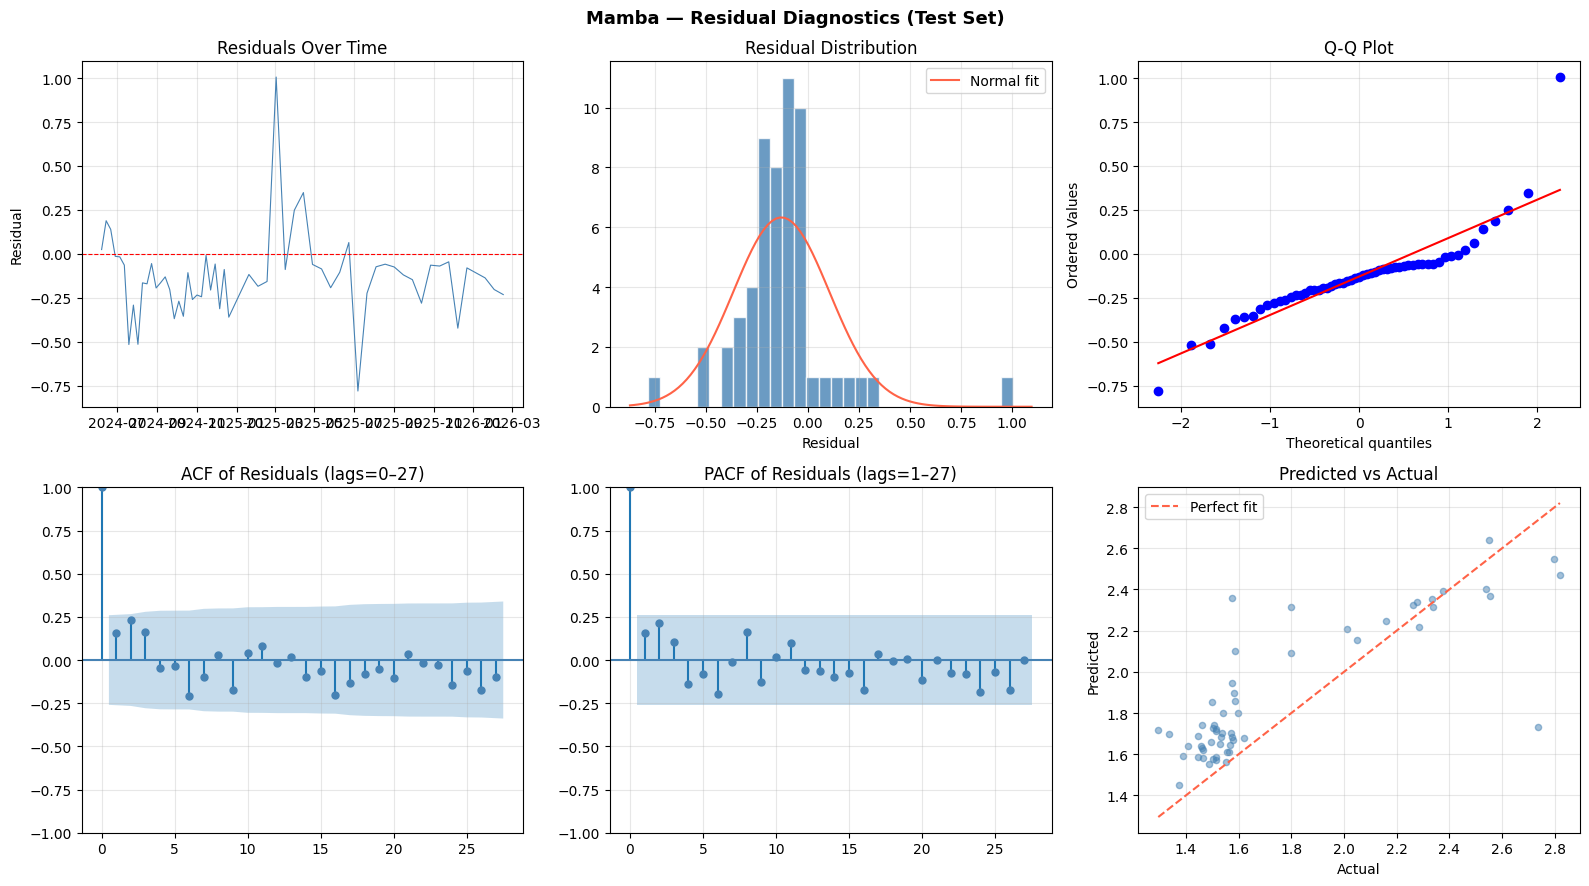

Diagnostics saved: mamba_diagnostics.png


In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Residuals over time
test_dates_plot = df.index[-len(residuals):]
axes[0,0].plot(test_dates_plot, residuals, color="steelblue", linewidth=0.8)
axes[0,0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0,0].set_title("Residuals Over Time")
axes[0,0].set_ylabel("Residual")
axes[0,0].grid(alpha=0.3)

# 2. Residual histogram
axes[0,1].hist(residuals, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
xmin, xmax = axes[0,1].get_xlim()
x = np.linspace(xmin, xmax, 100)
axes[0,1].plot(x,
    stats.norm.pdf(x, residuals.mean(), residuals.std()) * len(residuals) * (xmax-xmin)/30,
    color="tomato", linewidth=1.5, label="Normal fit")
axes[0,1].set_title("Residual Distribution")
axes[0,1].set_xlabel("Residual")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0,2])
axes[0,2].set_title("Q-Q Plot")
axes[0,2].grid(alpha=0.3)

max_lags = len(residuals) // 2 - 1

plot_acf(residuals,  lags=max_lags, ax=axes[1,0], color="steelblue")
axes[1,0].set_title(f"ACF of Residuals (lags=0–{max_lags})")
axes[1,0].grid(alpha=0.3)

plot_pacf(residuals, lags=max_lags, ax=axes[1,1], color="steelblue", method="ywm")
axes[1,1].set_title(f"PACF of Residuals (lags=1–{max_lags})")
axes[1,1].grid(alpha=0.3)

# 6. Predicted vs Actual scatter
axes[1,2].scatter(test_true_inv, test_pred_inv, alpha=0.5, color="steelblue", s=20)
mn, mx = test_true_inv.min(), test_true_inv.max()
axes[1,2].plot([mn, mx], [mn, mx], color="tomato", linewidth=1.5, linestyle="--", label="Perfect fit")
axes[1,2].set_xlabel("Actual")
axes[1,2].set_ylabel("Predicted")
axes[1,2].set_title("Predicted vs Actual")
axes[1,2].legend()
axes[1,2].grid(alpha=0.3)

plt.suptitle("Mamba — Residual Diagnostics (Test Set)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("mamba_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Diagnostics saved: mamba_diagnostics.png")

**Mamba State Space Model — UK Weekly Fruit & Vegetable Prices**

---

**Model Architecture and Training**

The Mamba model implements a selective state space architecture with two stacked Mamba blocks, a model dimension of 64, state dimension of 16, and a total of 129,665 trainable parameters. Input to the model is a 52-week lookback window of six features — weekly price, fuel price, CPI, API, fertiliser, and SPPI — all normalised via StandardScaler and aligned to the weekly price index through LOCF. The model was trained with Adam (lr = 1e-3, weight decay = 1e-5), gradient clipping at 1.0, and early stopping with patience of 20 epochs.

The training curve reveals a clear and concerning pattern: training loss decreases steadily across all 30 epochs, but validation loss diverges from approximately epoch 5 onward, climbing from ~0.35 to ~0.55 by the end of training. This is a textbook overfitting signature. The gap between train MSE (~0.10 at convergence) and validation MSE (~0.55) is substantial, indicating the model is memorising training sequences rather than learning generalisable price dynamics. Early stopping triggered at epoch 30, but the best validation state was saved from around epoch 4–5 where the gap was narrowest.

The 70/15/15 train/val/test split on 393 observations yields approximately 275 training, 59 validation, and 59 test sequences — a relatively small dataset for a model of this complexity, which likely explains the overfitting.

---

**Predictive Performance**

| Metric | Train | Validation | Test |
|---|---|---|---|
| RMSE | 0.1947 | 0.2782 | 0.2686 |
| MAE | 0.1129 | 0.2044 | 0.2003 |
| MASE | 0.9618 | 1.7416 | 1.7060 |
| MAPE | 7.50% | 11.70% | 11.93% |
| sMAPE | 7.91% | 10.88% | 11.17% |

The most important number in this table is the test MASE of 1.706. A MASE above 1.0 means the model performs *worse* than a naïve random walk benchmark on out-of-sample data — the single most meaningful red flag in the results. In-sample MASE of 0.96 confirms the model fits training data well (just below the naïve threshold), but this advantage completely disappears on held-out data. The validation and test MASE are nearly identical (~1.71), suggesting the degradation from training to unseen data is stable rather than worsening.

Test RMSE of 0.269 and MAE of 0.200 are numerically comparable to the ARIMA(2,0,0) results from earlier (RMSE 0.236, MAE 0.130), where ARIMA outperforms Mamba on both metrics. The test MAPE of 11.93% and sMAPE of 11.17% are reasonable in absolute terms — roughly 12% average error — but again the ARIMA baseline achieves this with far fewer parameters and without overfitting.

The AIC and BIC values (train AIC: 259,216; test AIC: 259,342) are extremely large, driven directly by the 129,665-parameter count entering the BIC penalty term. These should not be compared to the ARIMA information criteria from earlier sessions, as the scales are incomparable across model classes. They are only meaningful for comparing Mamba configurations against each other — for example, a smaller model with `d_model=32` or `n_layers=1` might achieve lower AIC/BIC with similar predictive accuracy.

---

**Test Set: Predicted vs Actual**

The time series plot of predicted versus actual values on the test set (June 2024 – February 2026) reveals a systematic bias: the model's predictions are consistently smoother and higher than the actual series during the low-price periods (mid-2024, late-2025), and lag the actual series during sharp spikes. The most notable failure is the March–April 2025 price spike, where the actual price reaches approximately 2.80 before rapidly collapsing — the model partially tracks the rise but then dramatically overshoots on the way down, predicting ~1.60 while the actual price had already dropped to ~1.45. This is characteristic of a model that has learned the general level and slow trend of the series but struggles with sharp, short-lived volatility events.

The predicted-vs-actual scatter plot confirms this: points cluster below the perfect-fit diagonal at low actual values (model predicts too high when prices are low) and above it at high actual values (model predicts too low at the peaks), indicating a systematic regression-to-the-mean tendency in the forecasts.

---

**52-Week Forecast**

The recursive 52-week ahead forecast from February 2026 through January 2027 shows an immediate jump from the last observed value (~1.40) to approximately 1.80 within the first few weeks, followed by complete flatness for the remainder of the forecast horizon. This flat convergence is a known limitation of recursive neural forecasting: after a few steps, the model's own predictions become the inputs, and the recurrent dynamics collapse toward a fixed point. The model has effectively learned a long-run mean of approximately 1.80 and converges to it rapidly once the actual historical signal is no longer available as input.

This makes the 52-week forecast uninformative for practical use — it tells us the model's estimated unconditional mean of the price index but provides no insight into seasonal patterns, trend, or uncertainty. By contrast, the Holt-Winters and STL+ARIMA forecasts produced seasonally-shaped trajectories with explicit prediction intervals, which are more actionable for stakeholders.

---

**Residual Diagnostics**

The residual diagnostics present a mixed picture. On the positive side, the Ljung-Box test at lag 20 returns p = 0.406, comfortably above the 0.05 threshold — confirming no significant autocorrelation in the test residuals. The ACF and PACF plots corroborate this, with all bars falling within the confidence bands beyond lag 1. This means the model has successfully extracted the linear temporal structure from the residuals, which is the primary diagnostic criterion for time series models.

However, the Jarque-Bera test returns p ≈ 0.000, decisively rejecting normality, with skewness of 1.64 and excess kurtosis of 11.42. The residual distribution is sharply right-skewed with a very heavy right tail — visible in the histogram where a large mass of small negative residuals sits to the left and a long right tail extends to +1.0. The Q-Q plot confirms this, with points tracking the normal line well in the centre but deviating sharply at both extremes, particularly the upper tail. The single large positive residual at +1.006 corresponds to the March 2025 spike where the model dramatically underestimated the actual price, and is the primary driver of the kurtosis.

The residual mean of −0.130 indicates a systematic negative bias — the model's predictions are on average 0.13 price index points too high relative to actuals, consistent with the visual observation that the model over-predicts during low-price periods. This bias, combined with non-normal residuals, means prediction intervals derived from Gaussian assumptions would be miscalibrated and should not be used for formal uncertainty quantification.

---

**Synthesis**

Mamba's selective state space mechanism is theoretically well-suited to time series with irregular update frequencies — exactly the mixed-frequency structure of this dataset. In practice, however, the model is limited by sample size. With only 393 aligned weekly observations (constrained by fertiliser data availability from 2017), a 129,665-parameter model is severely over-parameterised relative to the data, producing clear overfitting with test MASE above 1.0. The model captures the general level of the price series but fails on the sharp volatility events that matter most for practical forecasting.

For this dataset, the ARIMA(2,0,0) and STL+ARIMA models from earlier remain superior on all out-of-sample accuracy metrics. Mamba would likely become competitive with substantially more data — either by extending the historical window if earlier price records become available, or by training on a multi-commodity panel where each commodity-week pair forms a separate observation, dramatically increasing the effective sample size.